# April 2026 Mech Interp Puzzle: Max of List

by Dan Wilhelm [dan@danwil.com]

Herein we provide solutions for the [April 2026 puzzle: Max of List](https://puzzles.baulab.info/april-2026.html).

- We provide a cross-platform custom NumPy implementation, shown to be equivalent.
- We focus on showing the max() algorithm main path, rather than corner-cases and EOS production.

---
## Table of Contents

- [Setup code](#setup): Loads helper modules.
- [Sidebar](#sidebar): We show counterexamples that Puzzle 2 is not 100% accurate. We provide potential explanations in Appendix 3-3.
- [Sampling code](#sample): Samples activations from each model.

### [Puzzle 1](#puzzle1)
We introduce three experimental techniques that take advantage of the model's linearity (i.e. absence of layer norms), using them to solve Puzzle 1. We show that attention is sufficiently powerful to immediately find the maximum digit.

1. [(1-1)](#1-1) We analyze layer 0 attention scores via `S[E + P] = S[E] + S[P]` (E=embeds, P=positional embeds).
    - Using this, we show how heads independently use E and P to take the max, copy tens digit information, and copy previously-copied information.
2. [(1-2)](#1-2) We use logistic regression on head residual contributions (i.e. `W_V[hi] @ W_O[hi]`) to determine whether each head "knows" the true class.
    - We show head 3 places the max digit on the residual stream, alongside mostly per-class constants from the other heads.
3. [(1-3)](#1-3) We analyze layer 1 attention head logit attributions by partitioning W_O, e.g. for head hi: `W_V[hi] @ W_O[hi] @ W_U.T`.
    - We show that each head either outputs info about the true class`*`, or contributes a surprisingly uniform per-class bias.
    - Specifically, heads 0&2 reinforce head 3 in knowing and promoting only true classes 7-9 (which together are the maxes for >67% of all possible sequences).

### [Puzzle 2](#puzzle2)

- [(2-1)](#2-1) We first broadly visualize the below algorithm using a grid of logistic regression results.

Tens digit:
1. [(2-2)](#2-2) Layer 0 head 1 identifies the max tens digit as in Puzzle 1, copying it to the ANS residual row.
2. [(2-5)](#2-5) The max tens digit is already known and on the residual stream.
    - Hence, layer 1 heads (A) reinforce the true class (especially heads 1&2) and (B) provide per-class constants to properly match the unembeddings.

Ones digit:
1. [(2-3)](#2-3) Layer 0 heads 0&2: Attend to the ANS row, which we know from above contains the tens digit. This info is copied to the ANS+1 residual row.
2. [(2-4)](#2-4) Layer 0 head 3: Info about each tens digit is copied into the corresponding ones-digit activation rows.
3. [(2-6)](#2-6) Layer 1 heads 0&3: Recognize the max ones digit by (A) matching each (2-4) with (2-3) for a score boost, (B) applying a score gradient to the digits themselves, and (C) applying a mask on the ones digits via the positional embeds.

### Appendices
1. [(3-1)](#3-1) Ablation experiment results, particularly showing contribution of head 3 (puzzle 1) and puzzle 2 head combinations.
2. [(3-2)](#3-2) Attention pattern explorer.

`*` We refer to "output class" as a possible output token, and "true class" as the *correct* token.

---
<a id="setup"></a>
# Setup code

In [1]:
import torch as t
import numpy as np

import plotly_express as px
import matplotlib.pyplot as plt

from attention_only_model import AttentionOnlyModel
from helpers import (imshow, attn_logit_means, show_logit_contribs,
                     show_attn_gradient, logistic_accuracy, logistic_head_grid)

def where(cond):
    return np.nonzero(cond)[0]

device = "cuda" if t.cuda.is_available() else "mps" if t.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


In [2]:
# Show that NumPy-based model is equivalent to raw model
from helpers import load_models, tokenize_1, tokenize_2, examples_1, examples_2

raw_model_1, raw_model_2, model_1, model_2 = load_models(device)

# Verify model implementations the same
toks_1 = np.array([tokenize_1(nums) for nums in examples_1])
toks_2 = np.array([tokenize_2(nums) for nums in examples_2])

results_1, same_logits_1 = model_1.verify_raw_model(toks_1, raw_model_1)
results_2, same_logits_2 = model_2.verify_raw_model(toks_2, raw_model_2)

assert same_logits_1 and same_logits_2

Downloaded model definition + weights for both models.


In [3]:
# Useful constants
model_1.BOS_POS = 0; model_1.ONES_POS = 1; model_1.SEP_POS = 2
model_1.ANS_POS = 10; model_1.LAST_POS = 11

model_2.BOS_POS = 0; model_2.TENS_POS = 1; model_2.ONES_POS = 2; model_2.SEP_POS = 3
model_2.ANS_POS = 15; model_2.TENS_ANS_POS = 16; model_2.LAST_POS = 17

model_1.seq_labels = [ 'BOS', 'D0', 'SEP', 'D1', 'SEP', 'D2', 'SEP', 'D3', 'SEP', 'D4', 'ANS', 'Dmax', 'EOS' ]
model_2.seq_labels = [ 'BOS', 'T0', 'D0', 'SEP', 'T1', 'D1', 'SEP', 'T2', 'D2', 'SEP', 'T3', 'D3', 'SEP', 'T4', 'D4', 'ANS', 'Tmax', 'Dmax', 'EOS' ]

model_1.embed_labels = [f'E{i}' for i in range(model_1.n_digits)] + ['BOS', 'SEP', 'ANS', 'ANS+1']
model_2.embed_labels = model_1.embed_labels.copy()
#pos_labels = [f'P{i}' for i in range(model_1.n_digits)]

model_1.BOS = 10; model_2.BOS = 10
model_1.SEP = 11; model_2.SEP = 11
model_1.ANS = 12; model_2.ANS = 12
model_1.EOS = 13; model_2.EOS = 13

---
<a id="sidebar"></a>
## Sidebar: Puzzle 2 Model is not perfectly accurate

To avoid interrupting the mech interp flow, we first show via counterexample that the raw model does not always find the correct max.

This typically occurs with duplicated ones-digits, particularly when they are 0. Experiment with this below!
- **Note:** Running this overwrites any other model_2.run()

In [4]:
counterexample_seqs = [
    [ 0,  0,  4, 57, 63],
    [52, 49, 49, 28,  0],
    [81,  2, 10,  0,  7],
    [80, 12,  0,  0,  7],
    [45, 44, 44, 31, 23],
    [13, 15, 14, 14, 14],
]

toks = np.array([tokenize_2(seq) for seq in counterexample_seqs])
results, same_logits = model_2.verify_raw_model(toks, raw_model_2)

if same_logits:
    print(f'The raw and numpy models both incorrectly predict the max:\n')
    for i,seq in enumerate(counterexample_seqs):
        print(f'{i}', seq)
        print(f'\tcorrect answer: {max(seq)}, predictions -'\
              f' raw: {results[0][0][i]}{results[1][0][i]},'
              f' numpy: {results[0][1][i]}{results[1][1][i]}')
else:
    print(f'Logits not same between raw and numpy models.')

The raw and numpy models both incorrectly predict the max:

0 [0, 0, 4, 57, 63]
	correct answer: 63, predictions - raw: 53, numpy: 53
1 [52, 49, 49, 28, 0]
	correct answer: 52, predictions - raw: 52, numpy: 52
2 [81, 2, 10, 0, 7]
	correct answer: 81, predictions - raw: 91, numpy: 91
3 [80, 12, 0, 0, 7]
	correct answer: 80, predictions - raw: 90, numpy: 90
4 [45, 44, 44, 31, 23]
	correct answer: 45, predictions - raw: 44, numpy: 44
5 [13, 15, 14, 14, 14]
	correct answer: 15, predictions - raw: 14, numpy: 14


---
<a id="sampling"></a>
# Sampling code

We will use several techniques that rely on sampling the possible input distribution. We will generate these samples here for clarity.

- In Puzzle 1, we will capture activations for the complete set of 5^10 possible sequences.
- In Puzzle 2, we will also capture a random sample of 5^10 (of 100^10).

Note that in both puzzles, the true classes are highly imbalanced toward 7-9. This may explain why the model overall is biased toward larger maxes (e.g. when multiple heads are ablated in Appendix 1: Ablation Experiments), and also why additional heads are dedicated to these true classes (as shown in 1-3 and 2-5).

In [5]:
# PUZZLE 1: Quickly process and verify all possible 5-digit sequences
from itertools import product

# 5^10 == 100,000 possible sequences (via Cartesian product)
nums_1 = np.array(list(product(range(model_1.num_range), repeat=model_1.list_len)))
y_true_1 = np.max(nums_1, axis=-1)

seqs_1 = np.array([tokenize_1(seq) for seq in nums_1])
logits = model_1.run(seqs_1)
y_pred = np.argmax(logits[:,-1], axis=-1)
assert np.all(y_pred == y_true_1)    # 100% accuracy?

n_per_class_1 = {n: len(where(y_true_1 == n)) for n in range(model_1.num_range)}
print('The true output classes are highly imbalanced:')
print(n_per_class_1)

The true output classes are highly imbalanced:
{0: 1, 1: 31, 2: 211, 3: 781, 4: 2101, 5: 4651, 6: 9031, 7: 15961, 8: 26281, 9: 40951}


In [6]:
# PUZZLE 2: Randomly sample activations from 100,000 sequences
# (This may take 20+ seconds .. reduce n_examples as needed!)
n_examples = 100000

nums_2 = np.random.randint(0, model_2.num_range, size=(n_examples, model_2.list_len))
y_true_2 = np.max(nums_2, axis=-1)

base_seqs_2 = np.array([tokenize_2(seq) for seq in nums_2])
logits_tens = model_2.run(base_seqs_2)
pred_tens = np.argmax(logits_tens[:,-1], axis=-1)

seqs_2 = np.hstack([base_seqs_2, pred_tens[:,None]])
logits_ones = model_2.run(seqs_2)    # note pos=-2 contains the values from tens digit
pred_ones = np.argmax(logits_ones[:,-1], axis=-1)

y_pred = pred_tens*10 + pred_ones
if not np.all(y_pred == y_true_2):
    print('WARNING: The raw model does not properly find the max for:')
    incorrect_ixs = where(y_pred != y_true_2)
    for ix,seq in zip(incorrect_ixs,nums_2[incorrect_ixs]):
        print(f'predicted max: {np.argmax(logits_tens[ix,-1], axis=-1)}{np.argmax(logits_ones[ix,-1], axis=-1)}',
              seq.tolist())

n_per_class_2 = {n: len(where(y_true_2 == n)) for n in range(model_2.num_range)}
print('The true output classes are highly imbalanced:')
print(n_per_class_2)

The true output classes are highly imbalanced:
{0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 1, 12: 3, 13: 2, 14: 3, 15: 3, 16: 5, 17: 2, 18: 7, 19: 7, 20: 9, 21: 9, 22: 17, 23: 13, 24: 22, 25: 18, 26: 17, 27: 29, 28: 22, 29: 35, 30: 48, 31: 49, 32: 55, 33: 74, 34: 84, 35: 85, 36: 93, 37: 102, 38: 123, 39: 110, 40: 157, 41: 130, 42: 166, 43: 188, 44: 176, 45: 199, 46: 275, 47: 265, 48: 244, 49: 319, 50: 350, 51: 370, 52: 391, 53: 449, 54: 460, 55: 439, 56: 485, 57: 556, 58: 596, 59: 659, 60: 657, 61: 742, 62: 762, 63: 803, 64: 846, 65: 898, 66: 1017, 67: 1053, 68: 1153, 69: 1164, 70: 1184, 71: 1359, 72: 1388, 73: 1434, 74: 1559, 75: 1612, 76: 1669, 77: 1726, 78: 1933, 79: 1996, 80: 2118, 81: 2152, 82: 2319, 83: 2393, 84: 2614, 85: 2695, 86: 2791, 87: 2949, 88: 3048, 89: 3134, 90: 3353, 91: 3488, 92: 3700, 93: 3795, 94: 3915, 95: 4190, 96: 4404, 97: 4391, 98: 4667, 99: 5008}


---
<a id="puzzle1"></a>
# Puzzle 1 - Single-digit Max

Each sequence is of the form: `[ BOS, D0, SEP, D1, SEP, D2, SEP, D3, SEP, D4, ANS, Dmax, EOS ]`.

Our one-layer attention-only no-bias model must predict `EOS` and `Dmax = max(D0, D1, D2, D3, D4)`.

- Each `Di` is a one-digit number 0-9.

## Puzzle 1 Algorithm

Attention is sufficiently powerful to immediately find the maximum digit.
- Head 3 masks non-digits using the pos embeds, then assigns an increasing score to increasing embedding digits.
- Head 3 places the max digit on the residual stream, alongside mostly per-class constants from the other heads. This allows it to be immediately unembedded.
- Heads 0&2 reinforce head 3 in knowing and promoting only true classes 7-9 (which together are the maxes for >67% of all possible sequences).

To provide evidence toward this, we will:

1. (1-1) Show how attention computes max for head 3 (and for heads 0&2 for classes 7-9).
2. (1-2) Use logistic regression to esimate how much each head may contribute toward indentifying the true class.
3. (1-3) That the actual per-head logit contributions are consistent with these, either contributing per-class constants or true signal.

<a id="1-1"></a>
## 1-1. The layer 0 head 3 embedding-scores gradient computes max()
We can easily visualize this gradient by separately looking at the attention scores of embeds S[E] and positional embeds S[PE].
- For the layer 0 attention head scores, S[E+PE] = S[E] + S[PE].
- We only must examine the last row scores (ANS), since these are the only contributor to the next token prediction.

It is also important to understand some properties of softmax:
- Softmax effectively takes the max. So if an input has a larger score (deeper red in the diagram), it will be attended to.
    - This is why establishing a score gradient selects the maximum!
- Softmax is translation-invariant. So:
    - Constants do not affect the softmax output. We can hence center by the ANS position, or e.g. mean-center the unembedding matrix.
    - Positional embeds add a separate constant to even positions (separators) and odd positions (numbers).
        - This (1) ensures that only odd PEs will be attended to, and (2) the constant addition ensures it does not affect the gradient.

> Side note: Gradients are a common attention motif! For example to pay attention to the next-to-last token, models apply an increasing gradient on the positional embeds, making the last token score negative, ensuring it isn't selected.

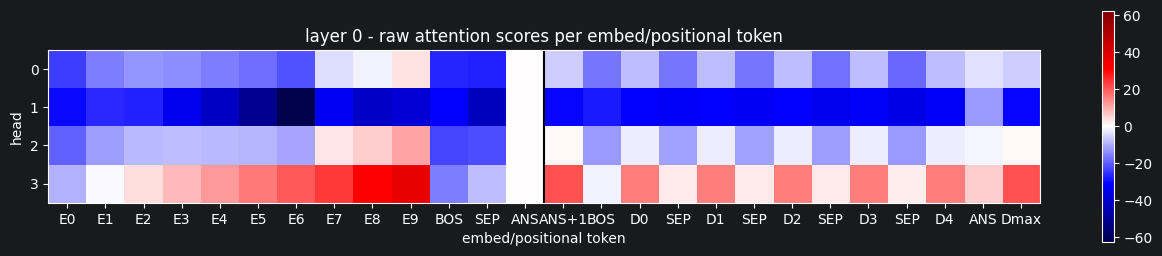

In [7]:
title = f'layer 0 - raw attention scores per embed/positional token'
show_attn_gradient(model_1, layer=0, title=title)   # relative to ANS

Note that heads 0&2 ALSO attend to some embeds E7-E9.
- This may be a consequence of class imbalance. >67% of the possible sequences have maxes that are 8 and 9.
- Hence, these heads may have learned to provide additional evidence to support the most common maxes.

<a id="1-2"></a>
## 1-2. How much does each head contribute to the true class?

To estimate how well each head may recognize the true class, let's first train a custom unembedding on each head's residual stream output:

In [8]:
# Let's try to train an unembedding matrix that decodes each head.
layer = 0; head = 3; pos = -1; n_samples = 1000

print('Per-head attn_result logistic regression accuracy')
for head in range(model_1.n_heads):
    X = model_1.attn_result[layer,:,head,pos]
    lr, lr_acc = logistic_accuracy(X, y_true_1 % 10, n_samples=n_samples)  # uses logistic regression
    print(f'head {head} accuracy: {lr_acc:.2f}')

print('accuracy accurately guessing 7, 8, or 9:',
      (n_per_class_1[7] + n_per_class_1[8] + n_per_class_1[9]) / sum(n_per_class_1.values()))

Per-head attn_result logistic regression accuracy
head 0 accuracy: 0.78
head 1 accuracy: 0.27
head 2 accuracy: 0.78
head 3 accuracy: 1.00
accuracy accurately guessing 7, 8, or 9: 0.83193


This aligns well with what may be possible from the attention scores above:
- Head 3 contains perfect info about the true class.
- Heads 0&2 contain substantial info about the true class (possibly ~accurately knowing classes 7,8,9)
- Head 1 does not attend to the digits much, but still may contribute toward common classes.

---
<a id="1-3"></a>
## 1-3. Other heads mostly contribute per-class constants/biases

We will now show that except for head 3 and heads 0&2 (for true-class E7-E9), the heads only contribute per-class biases to the output stream. This likely helps the model match the unembedding vectors, given the model lacks bias parameters.

Because the model is linear:
- We can compute (with partitioned W_O) per head hi: `W_V[hi] @ W_O[hi] @ W_U.T` which gives the contribution PER HEAD to the output logits.
- Note the pre-logit output is the sum of each head's contribution with the original embeddings!
- Upon analyzing these, we realize that most heads contribute extremely consistent per-class constants to the output stream.

We now present the relationship between each head's output logits and the true class. In the graph below, note that similar-height bars (w/ minimal std dev) indicate outputting a per-class constant, regardless of true class.

The conclusions are:
- Head 0 outputs constants, except for true classes 8-9 (possibly 7?).
- Head 1 only outputs constants.
- Head 2 outputs constants, except for true classes 7-9.
- Head 3 outputs uniquely for all classes, the only for classes <7.

In [9]:
title = f'Most heads output constant per-class biases/logits. (Note different y-axis scales, and heads 0-2 have no knowledge of true classes <7!)'

means, stds = attn_logit_means(model_1, y_true_1, tens_digit=False)
fig = show_logit_contribs(model_1, means, stds, layer=0, title=title, xaxis_ytrue=False)

These again perfectly compliment the above experiments, showing that indeed certain heads contribute to particular true-class logits only given certain true classes.

- Also recall that, given a known true class, the sum of the logits above ARE the final output logits! (There is also a small contribution from the skip connection! However, its norm is very small in comparison.)

- Although the plotted values are means, the standard deviations are very small. So, it likely is an accurate explanation of the overall mechanism (aside from potential corner cases).

In conclusion, we showed how attention computes max for head 3 (and for heads 0&2 for classes 7-9). We then used logistic regression to estimate how much each head may contribute to indentifying the true class. Finally, we showed this was consistent with the actual per-head logit contributions.

---
<a id="puzzle2"></a>
# Puzzle 2 - Two-digit Max

Each sequence is of the form: `[ BOS, T0, D0, SEP, T1, D1, SEP, T2, D2, SEP, T3, D3, SEP, T4, D4, ANS, Tmax, Dmax, EOS ]`.

Our two-layer attention-only no-bias model must predict `EOS` and `Nmax = max(10*T0+D0, 10*T1+D1, 10*T2+D2, 10*T3+D3, 10*T4+D4) = 10*Tmax + Dmax`.

- Each `Ti` and `Di` is a one-digit number 0-9, each pair interpreted as the two-digit number `Ni = Ti*10 + Di`.

---
## Puzzle 2 Algorithm

This puzzle ultimately uses the same mechanism as puzzle 1:
1. The first layer identifies the tens digit using a score embedding gradient + pos embed mask.
2. The second layer applies a similar embedding gradient, but masks using the tens digit (which has been incorporated into corresponding ones-digit residual rows).

> Note that in the first layer, attention can spread information across many activation rows. This often results in (1) redundancy, and (2) multiple paths to correct predictions. These often make simple-looking explanations somewhat but not entirely true. We show this in Appendix 2: Ablation Experiments, which show that single heads with interpretable patterns often are not required for accurate prediction.

Here is a specific breakdown of the mechanism, for future reference:

Tens digit:
1. (2-2) Layer 0 head 1 identifies the max tens digit as in Puzzle 1, copying it to the ANS residual row.
2. (2-5) The max tens digit is already known and on the residual stream.
    - Hence, layer 1 heads (1) reinforce the true class and (2) provide per-class constants to properly match the unembeddings.

Ones digit:
1. (2-3) Layer 0 head 0&2: Attend to the ANS row, which we know from above contains the tens digit. This info is copied to the ANS+1 residual row.
2. (2-4) Layer 0 head 3: Info about each tens digit is copied into its corresponding ones-digit activation rows.
3. (2-7) Layer 1 head 0&3: Recognize the ones digit by matching each (2) with (1). These are placed on the ANS+1 output residual row and unembedded.

<a id="2-1"></a>
# 2-1. How much is known about the true tens and ones after each attention layer?

Let's apply logistic regression again, as above. We should mention a few caveats using this method:
- Just because a true class _can_ be reconstructed doesn't mean the model uses this knowledge.
- The resulting class directions likely do not correspond to W_U, because 64 dimensions (far more than the 14 output classes) likely allow for numerous reconstruction vectors.
- For this reason, logistic regression vectors are different than W_U, so this DOES NOT CORRESPOND TO THE ACTUAL LOGITS.

With that said, we have a few really interesting findings that align with the above mechanism:
- Layer 0 identifies the heads digit using head 1 for ANS and heads 0&2 for ANS+1.
  - The latter is near-perfect only when combining head 0&2 outputs, e.g. try use_attn_out=True
  - As we'll see: (1) ANS head 1 computes the tens digit, and (2) ANS+1 heads 0&2 read from ANS, which contains the tens digit!
- Layer 1 heads have dual function -- 0&3 know about the ones digit, while 1&2 (and even ~0&3) know about the tens digit.
  - Interestingly, heads 1&2 ALWAYS contains near-perfect info about the tens digit, both for ANS and ANS+1!
    - These do not result in high logits, however, because their directions don't align with W_U as mentioned.

Again, note these colors are what is possible with custom unembedding matrices per square, they are NOT THE ACTUAL LOGITS.

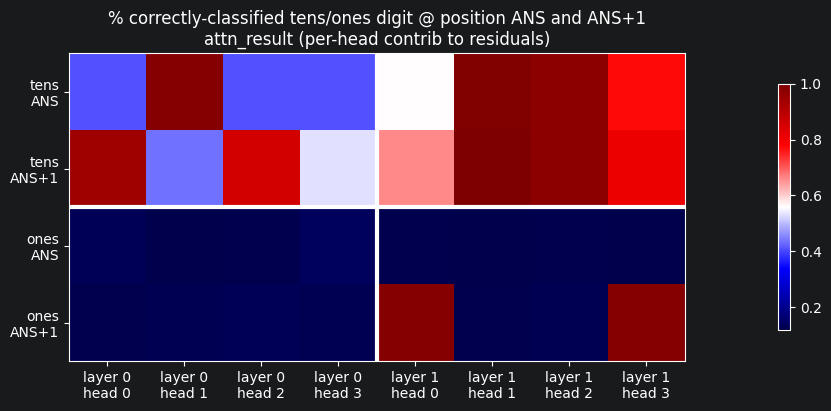

In [10]:
n_samples = 1000

# Try `use_unembed=True` to view per-head logit lens.
# Try `use_attn_out=True` to use the sum of all heads.
probas, head_labels = logistic_head_grid(model_2, y_true_2, n_samples=n_samples,
                                         use_unembed=False, use_attn_out=False)

title = '% correctly-classified tens/ones digit @ position ANS and ANS+1\nattn_result (per-head contrib to residuals)'
fig,axs = imshow(probas.reshape(-1, 4).T, title=title,
                 yticks=['tens\nANS', 'tens\nANS+1', 'ones\nANS', 'ones\nANS+1'],
                 xticks=head_labels, vmin=0.0, vmax=1.0, figsize=(24,4))
axs.axhline(1.5, c='w', linewidth=3); axs.axvline(3.5, c='w', linewidth=3);

Now that we have a general overview of the mechanism, let's provide evidence for each piece.

---
<a id="2-2"></a>
## 2-2. How is the max tens digit computed @ ANS?

> "Layer 0 head 1 identifies the max tens digit as in Puzzle 1, copying it to the ANS residual row."

Layer 0 head 1 in particular attends to the tens digit.
- Recall we can linearize the interactions via `S[E+P] = S[E] + S[P]`.
- Then we notice an increasing embedding gradient on increasing digits, combined with a pos embed mask on the tens digits (`Ti`).
- Note: You can verify these diagrams by looking at per-example attention patterns. To explore this interactively, see Appendix 1.

Despite this clear gradient, many heads below copy info and in layer 1!
- Hence, ablating head 1 still gives ~16% tens-place accuracy, higher than the 10% random baseline (see Appendix 2).

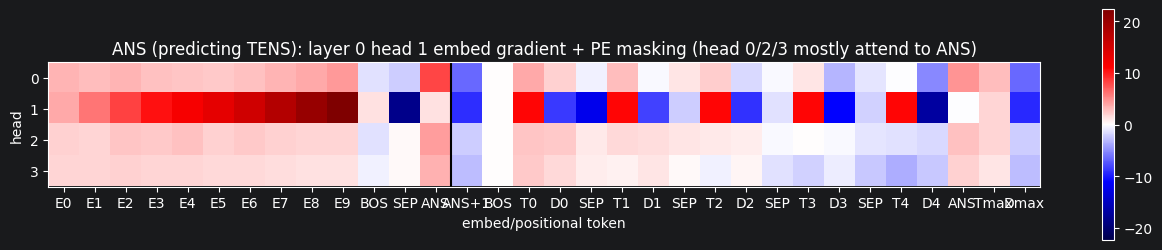

In [11]:
# Note these are raw attention scores, so highest attention probability on LARGEST present.
title = 'ANS (predicting TENS): layer 0 head 1 embed gradient + PE masking (head 0/2/3 mostly attend to ANS)'

# To predict the tens digit, we compute the attn scores row for when the token is ANS at position ANS_POS.
row = model_2.W_E[model_2.ANS] + model_2.W_P[model_2.ANS_POS]
show_attn_gradient(model_2, layer=0, title=title, sub_pos=model_2.ANS+2, row=row)

For layer 1 heads, we can no longer as easily split the embeds from the pos embeds -- they have passed through a non-linearity (the softmax!). Instead, we will take the mean of each layer 1 attn_in, for an approximation of their effect. Note since this is the mean, it is interesting but not completely representative of any particular example's behavior.

This mirrors what we observe from attention patterns -- that layer 1 heads 0&3 attend to BOS (constants), while heads 1&2 attend to ANS (contains the tens digit).
- We'll see later that layer 1 heads 0&3 are responsible for ones-digit detection.

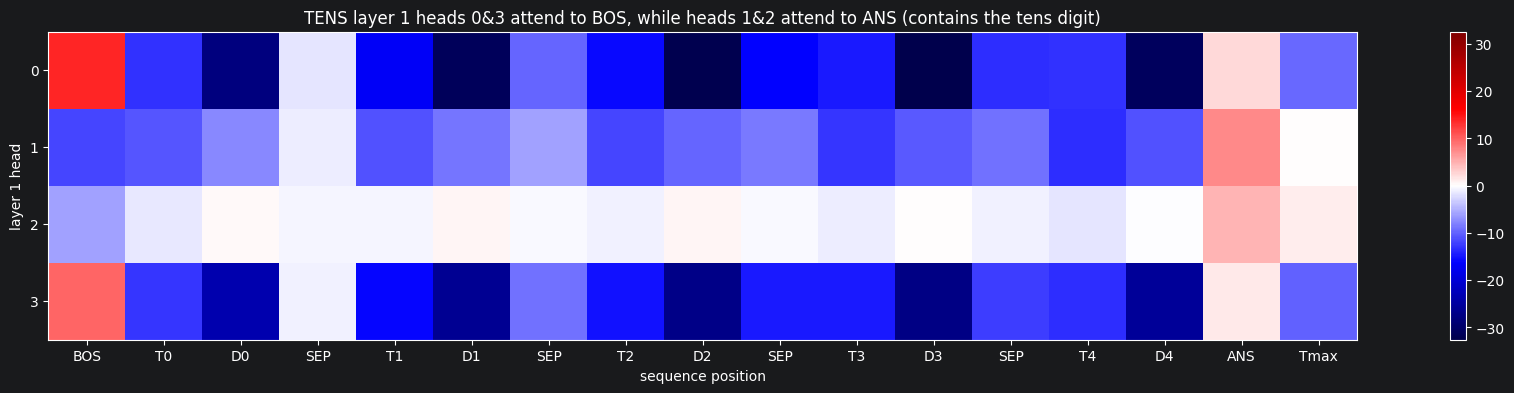

In [15]:
title = f'TENS layer 1 heads 0&3 attend to BOS, while heads 1&2 attend to ANS (contains the tens digit)'
layer = 1; n_samples = 1000; pos = -2 # tens digit

attn_in_pos = model_2.attn_in[layer,:n_samples].mean(axis=0)  # Average attn_in over each position
ans1_attn_in = attn_in_pos[[pos]]

scores = np.stack([model_2.quick_attn(layer,head, rows=ans1_attn_in, cols=attn_in_pos, softmax=False) for head in range(model_2.n_heads)])
fig,axs = imshow(scores.reshape(4, -1), title=title, colorbar=True, colorbar_scale=1.0,
                 xticks=model_2.seq_labels[:-2], yticks=np.arange(model_2.n_heads), center=True,
                 xlabel='sequence position', ylabel=f'layer {layer} head', figsize=(24,4));

<a id="2-3"></a>
## 2-3. How is the max tens digit copied to ANS+1?

Examining the same layer 0 heads, we now increment our embed pos from ANS_POS to ANS_POS+1. Similarly, instead of the ANS token we now have the actual tens digit in the ANS_POS position.

Making only this change to the "row" of our attention matrix, we see that for heads 1&3, the ANS position is now attended to (dark red).
- Interestingly, the pos embedding alone converts head 1 from a tens-computer to a tens-copier!

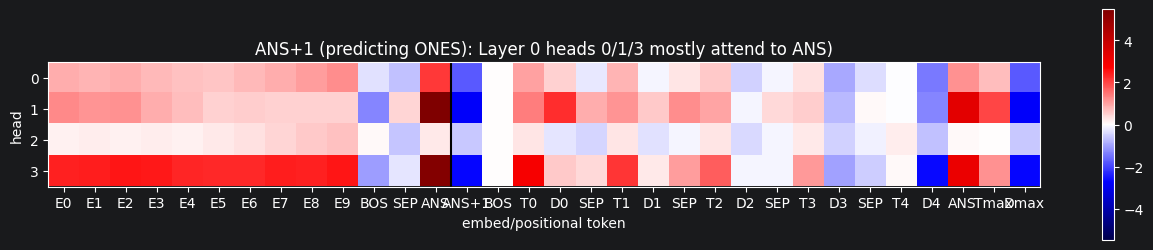

In [17]:
# Note these are raw attention scores, so highest attention probability on LARGEST present.
title = 'ANS+1 (predicting ONES): Layer 0 heads 0/1/3 mostly attend to ANS)'

tens_digit = 5  # Even changing the tens digit, ANS still has the largest score (dark red).
row = model_2.W_E[tens_digit] + model_2.W_P[model_2.ANS_POS+1]
show_attn_gradient(model_2, layer=0, title=title, sub_pos=model_2.ANS+2, row=row)

Note this is weak evidence alone that information is copied! We combine this with 1-1 to show attending to these likely is the cause of the tens digit now being on the residual stream.


---
<a id="2-4"></a>
# 2-4. How is each tens digit copied into the corresponding ones-digit activation row?

> "Layer 0 Head 3: Info about each tens digit is copied into its corresponding ones-digit activation rows."

**Main takeaway**: After layer 0, the ones digit activation rows now contain information about the tens digits! As we will show, this allows layer 1 heads to identify the correct ones.

- Recall this is layer 0, so in this model `S[E + PE] = S[E] + S[PE]`.
- On left, the embedding scores are small and ~equally attend to each other.
- On right, each ones digit attends to its corresponding tens digit (e.g. D0 attends to T0, the darkest red squares)
- As above, note there is redundancy. Although this head clearly copies the tens digit, other heads copy it some as well (as in the attn gradient above)!

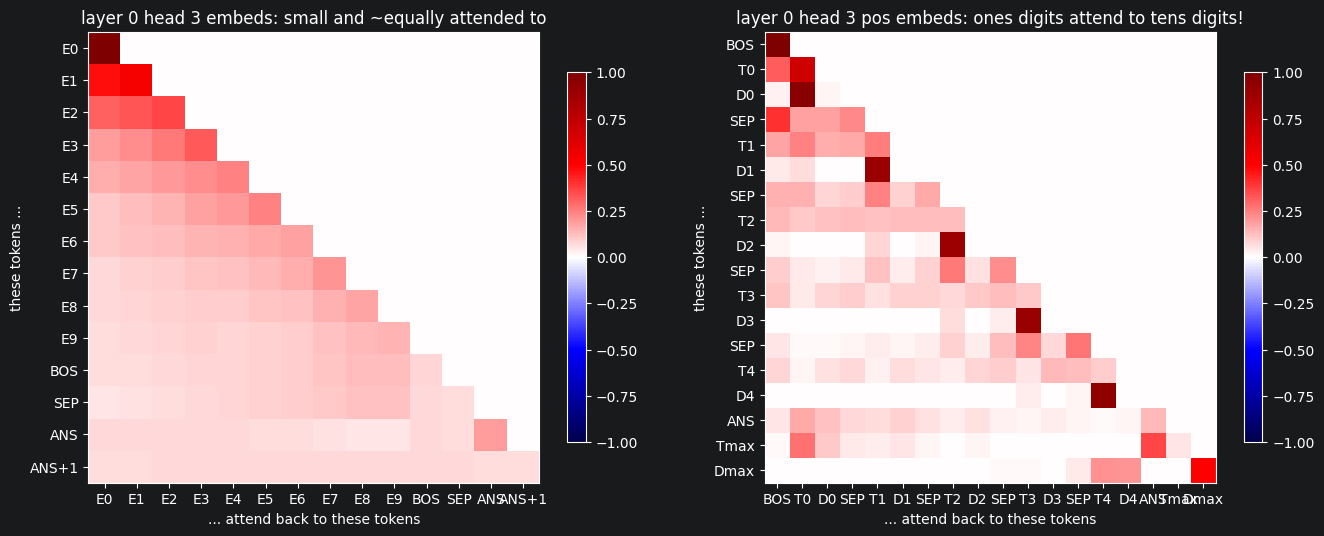

In [18]:
layer = 0; head = 3

# quick_attn creates an attention matrix with specified rows and cols for input residuals
scores = model_2.quick_attn(layer,head, rows=model_2.W_E,cols=model_2.W_E)
fig,axs = plt.subplots(1,2, figsize=(16,6))
imshow(scores, center=True, xlabel='... attend back to these tokens', ylabel='these tokens ...',
       xticks=model_2.embed_labels, yticks=model_2.embed_labels, axs=axs[0],
       title=f'layer {layer} head {head} embeds: small and ~equally attended to');

scores = model_2.quick_attn(layer,head, rows=model_2.W_P,cols=model_2.W_P)
imshow(scores, center=True, xlabel='... attend back to these tokens', ylabel='these tokens ...',
       xticks=model_2.seq_labels[:-1], yticks=model_2.seq_labels[:-1], axs=axs[1], colorbar=True,
       title=f'layer {layer} head {head} pos embeds: ones digits attend to tens digits!');

Hence, we show that layer 0 head 3 has a dual function -- it attends to ANS at position ANS+1, but it attends to the max tens digit in position ANS!

---
<a id="2-5"></a>
## 2-5. Which layer 1 heads are responsible for outputting the max tens and ones digits?

> "The max tens digit is already known and on the residual stream. Hence, layer 1 heads (1) reinforce the true class and (2) provide per-class constants to properly match the unembeddings."

This section performs an analysis of the per-head logit contributions.

Now for each head, let's determine which classes it is "responsible" for predicting (for both the tens and ones digits!). In summary:
- Head 0: [Tens] Identifies 5-8 (while negating 0-2).  [Ones] ~Same.
- Head 1: [Tens] Biases toward 0-4, identifies 9.  [Ones] Outputs constants (i.e. no true class signal).
- Head 2: [Tens] Biases toward 1-5, identifies 9. [Ones] Outputs constants (but high variance).
- Head 3: [Tens] Identifies 8-9. [Ones] ~Same.

In [19]:
# For the tens digit, head 0 identifies >= 5. head 1 <= 5. head 2 == 9, head 3 >= 8
title = 'TENS DIGIT Layer 1: Head 1 biases toward 0-4.\nHead 0 negates 0-2 when identifying 4-8, while head 2 identifies 9, head 4: 8-9.'
means, stds = attn_logit_means(model_2, y_true_2, tens_digit=True)
fig = show_logit_contribs(model_2, means, stds, layer=1, title=title, xaxis_ytrue=False)

By comparing the last and next graphs, note how similar some of the heads are -- they actually output similar classes despite being for the tens and ones digits!
- We know the tens digit is on the stream in both cases, each time partially copied there by layer 0 head 1. So it may activate heads similarly.
- Recall from 2-1 that heads 1&2 mostly output tens. This may be why the ones graph shows them outputting constants.
- Note that these conclusions are sometimes different from 2-1 because these use the ACTUAL unembeddings, while 2-1 uses custom unembeddings per head.

Finally, let's examine the ones digit layer 1 heads. You may ask -- how do the ones output true classes other than 5-9 (high in heads 0&3)?
- This is a result of the constants from head 1&2 being high in true classes <5, while the contributions of heads 0&3 are ~zero for the same.

In [20]:
# For the tens digit, head 0 identifies >= 5. head 1 <= 5. head 2 == 9, head 3 >= 8
title = 'ONES DIGIT Layer 1: Head 1&2 contribute ~constant per-class biases.\nHead 0 negates 0-2 when identifying 4-8, while head 3 identifies 8-9.'
means, stds = attn_logit_means(model_2, y_true_2, tens_digit=False)
fig = show_logit_contribs(model_2, means, stds, layer=1, title=title, xaxis_ytrue=False)

Recall this analysis uses means+stds -- it will miss any special cases which are used for a few inputs. However, we are very lucky that the standard deviations are extremely small, giving confidence in this case the conclusions generally hold.

Finally, note that the final logits are the sum of the head contributions from layers 0 and 1, plus the embeds (due to skip connections).
- We omitted the layer 0 and embeds graphs here, because their logit contributions are minor in comparison. However, you can view them simply by changing the layer parameter above!

---
<a id="2-6"></a>
## 2-6. How are the ones digits matched with the tens digits in layer 1?

> "Layer 1 heads 0&3: Recognize the max ones digit by (A) matching each (2-4) with (2-3) for a score boost, (B) applying a score gradient to the digits themselves, and (C) applying a mask on the ones digits via the positional embeds."

And now for the grand finale! We will show that layer 1 heads 0&3 match the tens digit information in the ANS+1 activations row (layer 0 head 1&3 @ANS+1) with the tens information stored in each ones digit activation row (layer 0 head 3 @<ANS). Using these as a mask, it then applies a score gradient across the masked ONES digits, placing the largest on the output residual stream!

Again for the ones digit, we will take the mean of each layer 1 attn_in, for an approximation of their effect:
- Interestingly, head 0&3 scores are ~opposite of pos -2 (ANS, the tens digit) which attend to BOS instead.

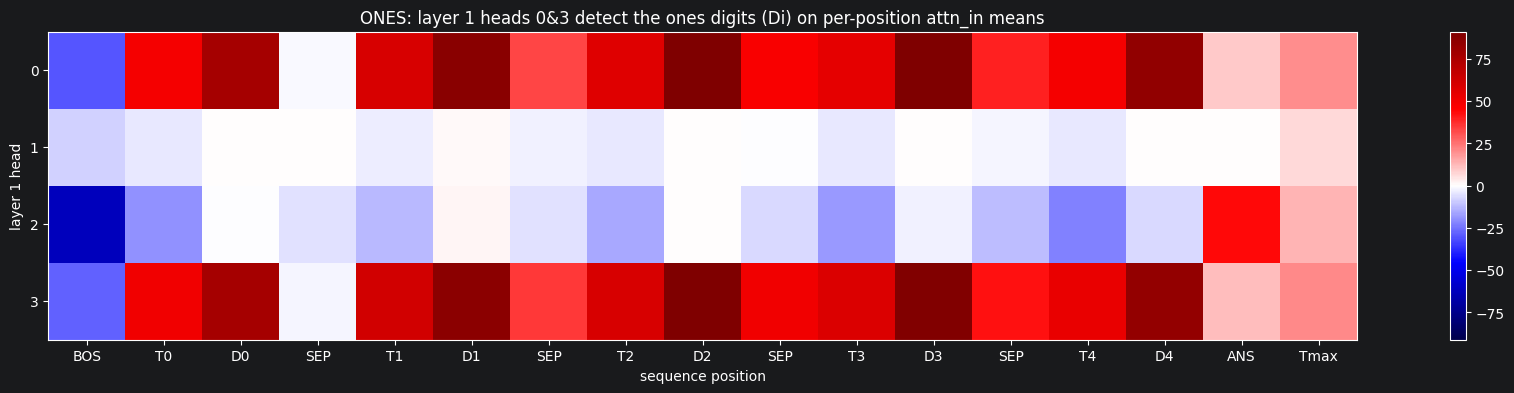

In [21]:
title = f'ONES: layer 1 heads 0&3 detect the ones digits (Di) on per-position attn_in means'
layer = 1; n_samples = 1000; pos = -1  # -2: tens digit, -1: ones digit

attn_in_pos = model_2.attn_in[layer,:n_samples].mean(axis=0)  # Average attn_in over each position
ans1_attn_in = attn_in_pos[[pos]]

scores = np.stack([model_2.quick_attn(layer,head, rows=ans1_attn_in, cols=attn_in_pos, softmax=False) for head in range(model_2.n_heads)])
fig,axs = imshow(scores.reshape(4, -1), title=title, colorbar=True, colorbar_scale=1.0,
                 xticks=model_2.seq_labels[:-2], yticks=np.arange(model_2.n_heads), center=True,
                 xlabel='sequence position', ylabel=f'layer {layer} head', figsize=(24,4));

So far we've shown that:
- Heads 0&3 output complete knowledge of the max ones digit, and 1&2 do not.
- Heads 0&3 seem to attend most to the ones digit sequence positions.

All remaining is to show (1) a score gradient on the ones digits, and (2) an extra score boost is given to THE ones digits following max tens. Observing attention patterns shows this ultimately works but is messy -- many of the ones digits have elevated scores.

Here we show that heads 0&3 apply a gradient to ones digits based on their corresponding tens digit:

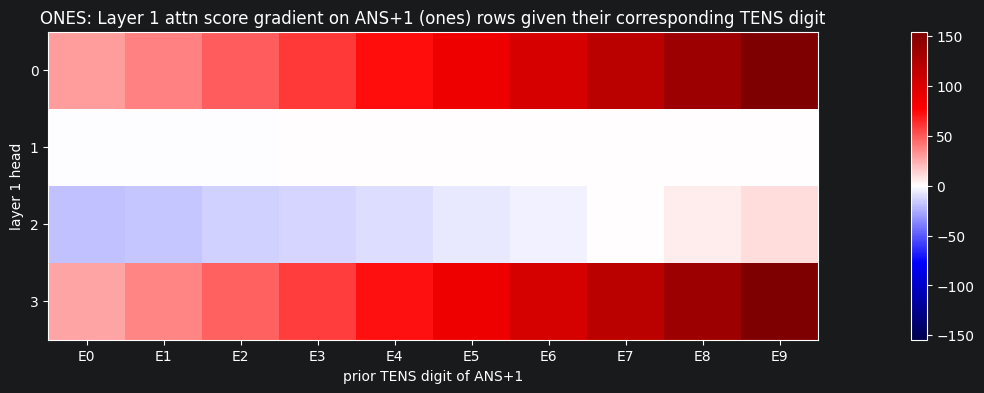

In [22]:
title = 'ONES: Layer 1 attn score gradient on ANS+1 (ones) rows given their corresponding TENS digit'
layer = 1; n_samples = 1000; pos = -1       # ANS+1
tens_seq_pos = np.array([1, 4, 7, 10, 13])  # positions of tens digits (for reference)
tens_pos = tens_seq_pos[4]                  # vary this to show the gradient applies to all positions!

# Average ANS+1 attn_ins based on their preceeding TENS digit
ones_attn_in = np.empty((model_2.n_digits, model_2.d_model))
for digit in range(0, model_2.n_digits):
    example_ixs = where(seqs_2[:,tens_pos] == digit)                          # for a particular tens digit ..
    if len(example_ixs) > 0:
        ones_attn_in[digit] = model_2.attn_in[layer,example_ixs,tens_pos+1].mean(axis=0)    # average the ONES digit rows following it!
    else:
        ones_attn_in[digit] = 0.0

ans1_attn_in = model_2.attn_in[layer,:n_samples,pos].mean(axis=0)[None]  # Average attn_in over each position

scores = np.stack([model_2.quick_attn(layer,head, rows=ans1_attn_in, cols=ones_attn_in, softmax=False) for head in range(model_2.n_heads)])
fig,axs = imshow(scores.reshape(4, -1), title=title, colorbar=True, colorbar_scale=1.0,
                 xticks=model_2.embed_labels[:-4], yticks=np.arange(model_2.n_heads), center=True,
                 xlabel='prior TENS digit of ANS+1', ylabel=f'layer {layer} head', figsize=(24,4));

Now for the final step, showing a score boost is given to the ONES digit corresponding to the max tens digit.
- Instead of averaging over ANS+1, we will choose one corresponding to a particular tens digit.

Note the ACTUAL prior tens can never be greater than the max tens, so there is an increasing gradient the closer the max tens digit is to each actual one.
This is likely responsible for the score boost. (Note the 0 row is likely not in our sample.)


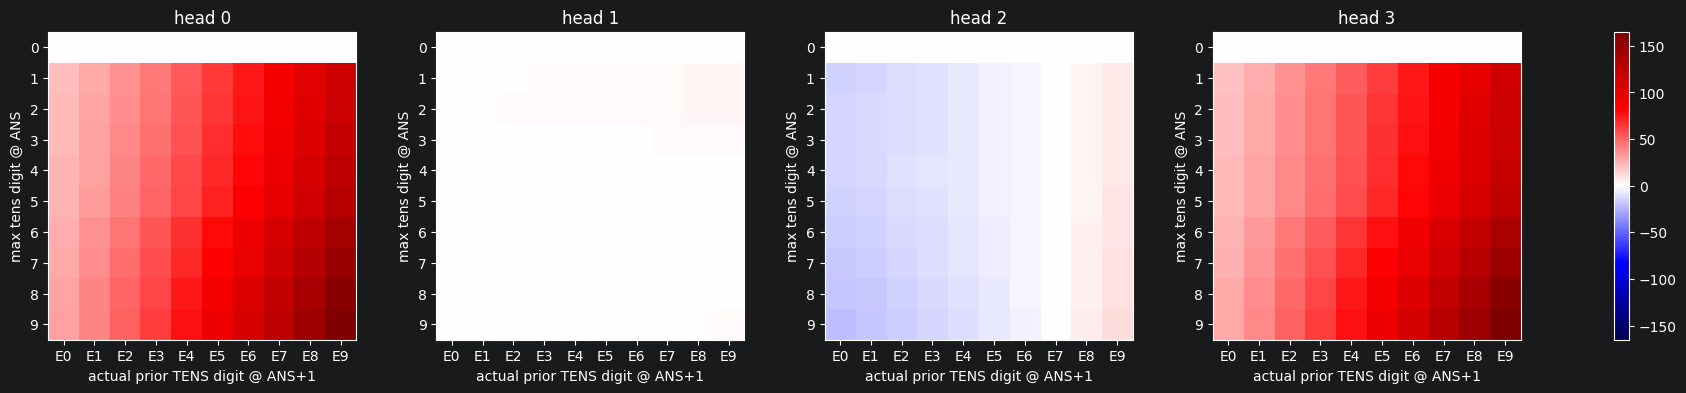

In [23]:
title = 'ONES: Layer 1 attn score gradient on ANS+1 (ones) rows given their corresponding TENS digit'
max_tens_digit = 8
layer = 1; n_samples = 1000; pos = -1       # ANS+1
tens_seq_pos = np.array([1, 4, 7, 10, 13])  # positions of tens digits (for reference)
tens_pos = tens_seq_pos[4]                  # vary this to show the gradient applies to all positions!

# cols: Average ANS+1 attn_ins based on their preceding TENS digit
ones_attn_in = np.empty((model_2.n_digits, model_2.d_model))
for digit in range(0, model_2.n_digits):
    example_ixs = where(seqs_2[:,tens_pos] == digit)  # for a particular tens digit ..
    if len(example_ixs) > 0:
        ones_attn_in[digit] = model_2.attn_in[layer,example_ixs,tens_pos+1].mean(axis=0)    # average the ONES digit rows following it!
    else:
        ones_attn_in[digit] = 0.0

# rows: Average attn_in at the ANS+1 position based on the ACTUAL max tens digit
ans1_attn_in = np.empty((model_2.n_digits, model_2.d_model))
for max_tens_digit in range(0, model_2.n_digits):
    example_ixs = where((y_true_2 // 10 == max_tens_digit) & (seqs_2[:,tens_pos] == max_tens_digit))
    if len(example_ixs) > 0:
        ans1_attn_in[max_tens_digit] = model_2.attn_in[layer,example_ixs,pos].mean(axis=0)  # Average attn_in over each position
    else:
        ans1_attn_in[max_tens_digit] = 0.0

scores2 = np.stack([model_2.quick_attn(layer,head, rows=ans1_attn_in, cols=ones_attn_in, softmax=False) for head in range(model_2.n_heads)])
fig,axs = imshow(scores2, facet_col=0, colorbar=True, colorbar_scale=1.0, title='head',
                 xticks=model_2.embed_labels[:-4], yticks=np.arange(model_2.n_digits), center=True,
                 xlabel='actual prior TENS digit @ ANS+1', ylabel=f'max tens digit @ ANS', figsize=(24,4));
print('Note the ACTUAL prior tens can never be greater than the max tens, so there is an increasing gradient the closer the max tens digit is to each actual one.')
print('This is likely responsible for the score boost. (Note the 0 row is likely not in our sample.)')

Note the above analysis is not causal. It relies on mean-class vectors which may be coincidental or not representative of many cases!


---
<a id="3-1"></a>
### Appendix 1: Head ablation experiment

Here, we verify some of the results above by ablating heads. Note this is often difficult to interpret, because as heads become ablated the model relies on other biases which may actually INCREASE the accuracy due to class imbalance.
- For example, when all puzzle 2 layer 0 heads are ablated, it gets 43% accuracy by simply guessing the most-common maxes!
- Also note that many heads contribute per-class logit biases. Ablating these alone may cause a large accuracy disruption.

Interesting things to try that we concluded above (note the %s depend on the random sample):
- Puzzle 1: Layer 0 head 3 is required to accurately detect classes 0-6, and ablating heads 1&3 reduces accuracy to ~9%.
- Puzzle 2: TENS - Ablating layer 0 head 1 (which detects the tens digit) reduces the tens-digit accuracy to ~16%, still higher than chance!
- Puzzle 2: ONES - Ablating layer 0 head 0&2 (which copy the ANS row) still gets ~59% accuracy, possibly because ANS is also copied by other heads but less prominently.
- Puzzle 2: ONES - Ablating layer 0 head 3 (which copies the tens to the ones) along with head 2 reduces accuracy to ~9%
- Puzzle 2: ONES - Layer 1 heads 0&3 are required to accurately detect the ones digit (reducing it to ~9% just by ablating 3).
- Puzzle 2: TENS - Layer 1 heads 1&2 (and somewhat 3) output the tens digit (ablating 1&2/1&3 reduces tens accuracy to ~9%/2%).

In [24]:
# ABLATION EXPERIMENT - ablating layer 0 head 3 results in layer 1 heads 0/3 not detecting the ones
# WARNING: These experiments overwrite stored activations. So you must re-run code at the top that runs 100,000 samples.
from collections import Counter

def all_ablations(model, seqs, head_subsets, ablate_layer):
    preds = np.empty((len(seqs), len(head_subsets)), dtype=int)
    for headi,head_ixs in enumerate(head_subsets):
        ablated_logits = model.run_ablate_head(seqs, ablate_layer, head_ixs)
        preds[:,headi] = np.argmax(ablated_logits[:,-1], axis=-1)
    return preds

head_subsets = [  # Empty set must be first for accuracy comparison!
    [], [0], [1], [2], [3],
    [0,1], [0,2], [0,3], [1,2], [1,3], [2,3],
    [0,1,2], [0,1,3], [0,2,3], [1,2,3], [0,1,2,3]
]

In [26]:
# ONES_POS = True is the ones digit / False is the tens digit
PUZZLE_1 = True; ONES_POS = True; n_seqs = 1000; ablate_layer = 0

m = model_1 if PUZZLE_1 else model_2; layer = 0 if PUZZLE_1 else layer
use_seqs = seqs_1[:n_seqs] if PUZZLE_1 else (seqs_2[:n_seqs] if ONES_POS else base_seqs_2[:n_seqs])

preds = all_ablations(m, use_seqs, head_subsets, ablate_layer=ablate_layer)
for headi, head_ix in enumerate(head_subsets):
    print(f'{np.mean(preds[:,headi] == preds[:,0]):.2f}', head_ix, Counter(preds[:,headi]))

1.00 [] Counter({np.int64(9): 271, np.int64(8): 217, np.int64(7): 169, np.int64(6): 127, np.int64(5): 91, np.int64(4): 61, np.int64(3): 37, np.int64(2): 19, np.int64(1): 7, np.int64(0): 1})
0.40 [0] Counter({np.int64(8): 657, np.int64(6): 218, np.int64(5): 61, np.int64(3): 37, np.int64(2): 19, np.int64(0): 8})
1.00 [1] Counter({np.int64(9): 271, np.int64(8): 217, np.int64(7): 169, np.int64(6): 127, np.int64(5): 91, np.int64(4): 61, np.int64(3): 37, np.int64(2): 19, np.int64(1): 5, np.int64(0): 3})
0.54 [2] Counter({np.int64(6): 398, np.int64(8): 308, np.int64(7): 267, np.int64(2): 19, np.int64(0): 4, np.int64(1): 4})
0.29 [3] Counter({np.int64(2): 343, np.int64(9): 271, np.int64(7): 218, np.int64(3): 168})
0.40 [0, 1] Counter({np.int64(9): 657, np.int64(6): 279, np.int64(4): 34, np.int64(1): 19, np.int64(0): 8, np.int64(3): 3})
0.15 [0, 2] Counter({np.int64(6): 806, np.int64(8): 167, np.int64(2): 19, np.int64(0): 8})
0.46 [0, 3] Counter({np.int64(9): 488, np.int64(2): 343, np.int64(7):

---
<a id="3-2"></a>
## Appendix 2: Attention Explorer

nums: [ 4 43 34 23 70]
 seq: [10  0  4 11  4  3 11  3  4 11  2  3 11  7  0 12  7]


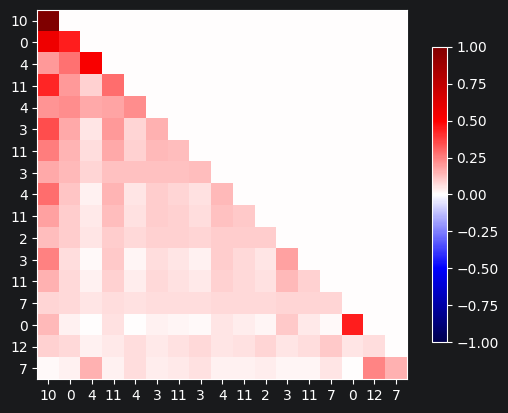

In [27]:
# Note: In Puzzle 2, the last row is the first max tens digit!
PUZZLE_1 = False; SHOW_SCORES = False
layer = 1; head = 0
example_ix = 0

m = model_1 if PUZZLE_1 else model_2; acts = m.scores if SHOW_SCORES else m.pattern
use_seqs = seqs_1 if PUZZLE_1 else seqs_2
print('nums:', nums_1[example_ix] if PUZZLE_1 else nums_2[example_ix])
print(' seq:', use_seqs[example_ix])

#example_ix = where(use_seqs[:,-1] == 1)[0]                             # select a specific digit
#example_ix = where((use_seqs[:,-2] == 1) & (use_seqs[:,-1] == 1))[0]   # select a specific tens+ones digit

n_toks = len(use_seqs[example_ix])
imshow(acts[layer,example_ix,head, :n_toks,:n_toks], center=True,
       xticks=use_seqs[example_ix], yticks=use_seqs[example_ix]);